In [1]:
# ==============================================================================
# BÖLÜM 45: GÜN 56: KNN ALGORİTMASI — KURSU GEÇME NOTLARI
# ==============================================================================

# ------------------------------------------------------------------------------
# 🎯 DERS 237: KNN Algoritması Giriş
# ------------------------------------------------------------------------------
# MANTIK: "Bana arkadaşını söyle, sana kim olduğunu söyleyeyim."
#         Yeni gelen veriyi, ona en yakın K tane komşusuna bakarak tahmin eder.
# ADIM 1: Bilinmeyen verinin diğer tüm verilere olan uzaklığını (Öklid vb.) ölçer.
# ADIM 2: En yakın K komşuyu seçer ve oy çokluğuna göre sınıfı belirler.


# ------------------------------------------------------------------------------
# 🎯 DERS 238: KNN Sınıflandırma ve Regresyon Farkı
# ------------------------------------------------------------------------------
# 1. SINIFLANDIRMA (Classification): Kesikli/Kategorik değerleri tahmin eder.
#    - Mantık: Komşularda oy çokluğu hangi sınıftaysa yeni veri de o sınıftır.
#    - Örnek : "Bu çiçek Tür 0 mı, Tür 1 mi?" -> En yakın 3 komşudan 2'si Tür 1 ise cevap Tür 1'dir.
#
# 2. REGRESYON (Regression): Sürekli/Sayısal değerleri tahmin eder.
#    - Mantık: En yakın komşuların hedef değerlerinin ortalamasını alır.
#    - Örnek : "Bu evin fiyatı ne kadar?" -> En yakın 3 komşu evin fiyat ortalamasını hesaplar.


# ------------------------------------------------------------------------------
# 🎯 DERS 239: KNN Optimizasyonu Zaman Maliyeti
# ------------------------------------------------------------------------------
# PROBLEM : KNN "Lazy Learner" (Tembel Öğrenici) bir algoritmadır. Eğitim aşaması yoktur.
#           Asıl yük test/tahmin anındadır; çünkü her yeni veri için tüm veri setindeki 
#           mesafeleri tek tek yeniden hesaplar. 
# MALİYET : Büyük veri setlerinde tahmin süresi çok uzar (Zaman maliyeti yüksektir: O(N*D)).
# ÇÖZÜM   : Veriyi küçük tutmak, KD-Tree veya Ball-Tree gibi özel veri yapıları kullanmak,
#           ya da mesafe hesabı kolaylaşsın diye veriyi mutlaka "Standartlaştırmak".



In [4]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

In [6]:
df = pd.read_csv("12-health_risk_classification.csv")

In [7]:
df.head()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1


In [8]:
# bmi -> vucut ktle endeksi
# blood -> tansiyon degisimi
# activity -> ne kaddar aktif bir yassam suruyor
# higt risk -> risk seviyesi


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bmi_score                 1000 non-null   float64
 1   blood_pressure_variation  1000 non-null   float64
 2   activity_level_index      1000 non-null   float64
 3   high_risk_flag            1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


In [10]:
df.describe()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.023702,0.016769,-0.020771,0.498000
std,1.203694,1.268761,1.392738,0.500246
min,-4.743951,-2.587178,-4.999018,0.000000
25%,-0.796655,-0.981320,-1.057938,0.000000
50%,0.142105,-0.317137,0.204506,0.000000
75%,0.956225,1.017388,1.061181,1.000000
max,2.321480,3.954873,3.477210,1.000000


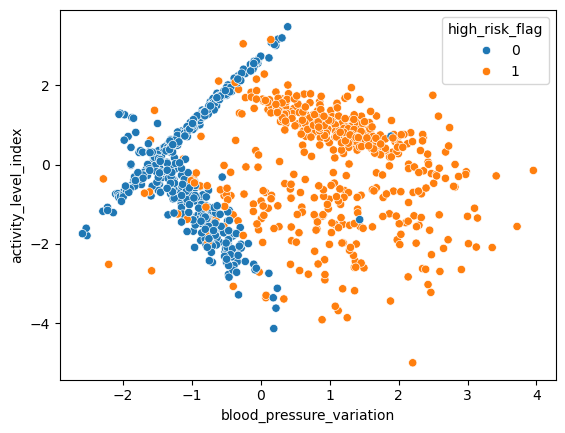

In [11]:
sns.scatterplot(x=df["blood_pressure_variation"],y=df["activity_level_index"],hue=df["high_risk_flag"])
plt.show()

In [12]:
df["high_risk_flag"].value_counts()

high_risk_flag
0    502
1    498
Name: count, dtype: int64

In [13]:
# datamiz balance bir data

In [14]:
X = df.drop("high_risk_flag",axis=1)
y = df["high_risk_flag"]

In [15]:
from sklearn.model_selection import train_test_split 

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [18]:
X_train.head()

,bmi_score,blood_pressure_variation,activity_level_index
846,-0.011863,1.504999,1.082829
969,-0.095340,-0.970397,-0.841670
191,-0.290911,1.452375,0.655629
711,-0.063187,1.078191,0.699556
967,-1.001080,1.866227,-0.031447


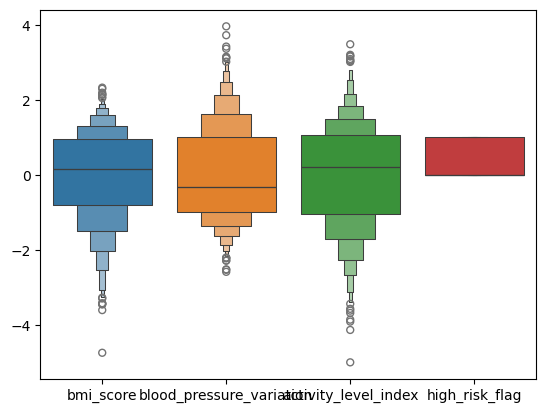

In [20]:
sns.boxenplot(df)
plt.show()

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [23]:
X_train_scaler  = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [33]:
from sklearn.neighbors import KNeighborsClassifier

In [40]:
classfier = KNeighborsClassifier(n_neighbors=5,algorithm="auto",weights="uniform")

In [41]:
# n_neighbors: En yakın 5 komşunun (verinin) ortalamasını alır.
# algorithm: En hızlı arama yöntemini otomatik belirler.
# weights: Seçilen 5 komşunun da tahmine etkisi eşittir.

In [42]:
classfier.fit(X_train_scaler,y_train)

KNeighborsClassifier()

In [43]:
y_pred = classfier.predict(X_test_scaler)

In [44]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [45]:
print("confusion matrix: \n ",confusion_matrix(y_pred,y_test))
print("accuracy score",accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

confusion matrix: 
  [[124  10]
 [  2 114]]
accuracy score 0.952
              precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [46]:
classfier = KNeighborsClassifier(n_neighbors=5,algorithm="kd_tree",weights="uniform")
classfier.fit(X_train_scaler,y_train)

KNeighborsClassifier(algorithm='kd_tree')

In [47]:
y_pred = classfier.predict(X_test_scaler)
print("confusion matrix: \n ",confusion_matrix(y_pred,y_test))
print("accuracy score",accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

confusion matrix: 
  [[124  10]
 [  2 114]]
accuracy score 0.952
              precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [48]:
# kd_tree yada auto arasinda cok bir fark yok sadece calisma hizi farkkli

In [49]:
classfier = KNeighborsClassifier(n_neighbors=3,algorithm="kd_tree",weights="uniform")
classfier.fit(X_train_scaler,y_train)

KNeighborsClassifier(algorithm='kd_tree', n_neighbors=3)

In [50]:
y_pred = classfier.predict(X_test_scaler)
print("confusion matrix: \n ",confusion_matrix(y_pred,y_test))
print("accuracy score",accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

confusion matrix: 
  [[125   9]
 [  1 115]]
accuracy score 0.96
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       134
           1       0.93      0.99      0.96       116

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



In [51]:
# komusu sayisini az bir sey degistirerek abartmadan daha iyi bir sonuc elde edebiliriz 

In [52]:
# buraya kadar olan kisimda KNN siniflandirma icin kullandik bundan sonra ki kismi regresyon icin kullanicaz

In [53]:
df_reg = pd.read_csv("12-house_energy_regression.csv")

In [55]:
df_reg.head()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530


In [56]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_indoor_temp_change        1000 non-null   float64
 1   outdoor_humidity_level        1000 non-null   float64
 2   daily_energy_consumption_kwh  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


In [57]:
df_reg.describe()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
count,1000.000000,1000.000000,1000.000000
mean,0.033186,0.056982,1.766025
std,0.961603,1.014959,41.299085
min,-3.241267,-2.940389,-132.797922
25%,-0.611581,-0.651418,-25.600072
50%,0.036043,0.047742,1.065474
75%,0.648317,0.714886,28.766573
max,3.078881,3.852731,138.577662


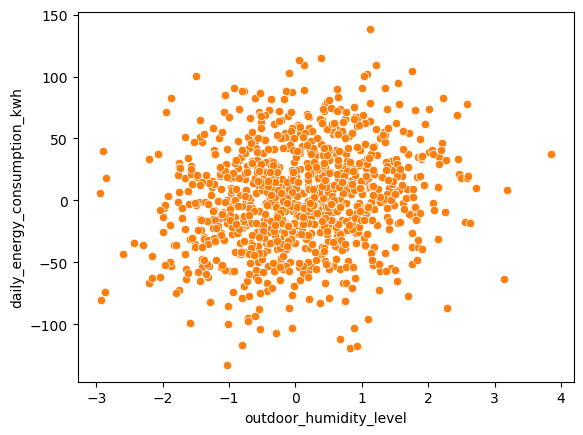

In [64]:
sns.scatterplot(x=df_reg["outdoor_humidity_level"],y=df_reg["daily_energy_consumption_kwh"])
plt.show()

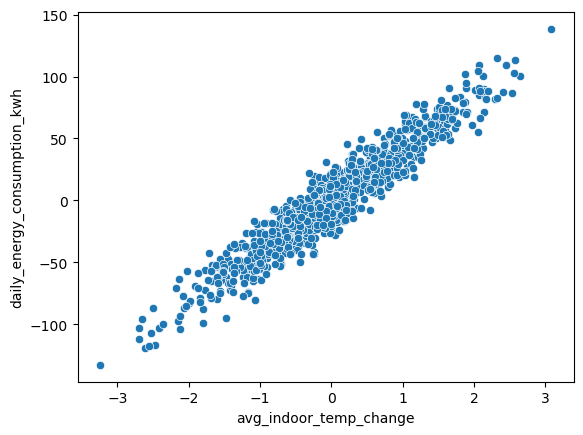

In [66]:
sns.scatterplot(x=df_reg["avg_indoor_temp_change"],y=df_reg["daily_energy_consumption_kwh"])
plt.show()

In [67]:
# 2 . tablo etki oraninin daha iyi anliyoruz yani sicaklik etkisi daha buyukmus daha etkiliymis bizim icin

In [68]:
df_reg.corr()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
avg_indoor_temp_change,1.000000,0.002584,0.956682
outdoor_humidity_level,0.002584,1.000000,0.169557
daily_energy_consumption_kwh,0.956682,0.169557,1.000000


In [69]:
X = df_reg.drop('daily_energy_consumption_kwh',axis=1)
y = df_reg['daily_energy_consumption_kwh']

In [70]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)

In [71]:
X_train.head()

,avg_indoor_temp_change,outdoor_humidity_level
846,0.799942,-1.616311
969,0.122298,0.543298
191,-0.186872,-0.439731
711,0.293558,-1.356582
967,1.390208,0.557810


In [73]:
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [74]:
from sklearn.neighbors import KNeighborsRegressor

In [77]:
regressor = KNeighborsRegressor(n_neighbors=5,algorithm='auto')

In [78]:
regressor.fit(X_train_scaler,y_train)

KNeighborsRegressor()

In [79]:
y_pred = regressor.predict(X_test_scaler)

In [80]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [82]:
print('mean absolute error',mean_absolute_error(y_test,y_pred))
print('mean squared error',mean_squared_error(y_test,y_pred))
print('r2 score',r2_score(y_test,y_pred))

mean absolute error 9.228754406902722
mean squared error 135.6610827281179
r2 score 0.9183109118983248


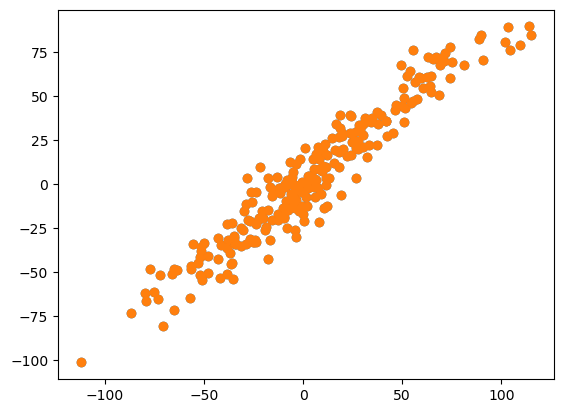

In [84]:
plt.scatter(y_test,y_pred)
plt.show()

mean absolute error 9.326118628600977
mean squared error 134.62063167240598
r2 score 0.9189374253850693


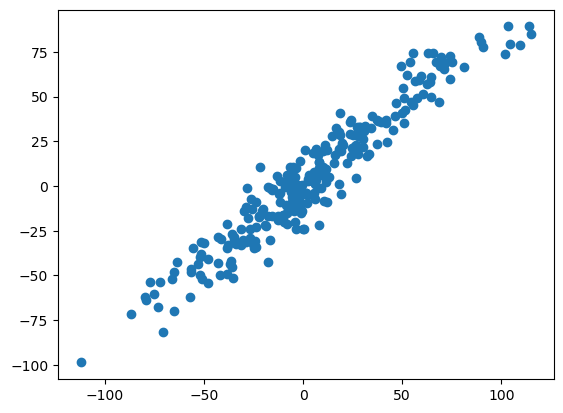

In [86]:
regressor = KNeighborsRegressor(n_neighbors=7,algorithm='auto')
regressor.fit(X_train_scaler,y_train)
y_pred = regressor.predict(X_test_scaler)
print('mean absolute error',mean_absolute_error(y_test,y_pred))
print('mean squared error',mean_squared_error(y_test,y_pred))
print('r2 score',r2_score(y_test,y_pred))
plt.scatter(y_test,y_pred)
plt.show()

In [87]:
# 7 yaptik komsuyu cok bir sey degismedi